In [68]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.offline as py 
py.init_notebook_mode(connected=True)                  
import plotly.graph_objs as go                         
import plotly.tools as tls                             
from collections import Counter                        
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV                                         # to split the data
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve, r2_score, accuracy_score, confusion_matrix, classification_report, fbeta_score     # to evaluate our model
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

import warnings
import missingno as msno
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")

pd.pandas.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

2. Exploration Data Analysis (EDA)

In [69]:
import pandas as pd
df = pd.read_csv("data.csv", sep=';', encoding='latin1')


In [70]:
# The first 5 observation units of the data set were accessed.
df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,160,100,84,18,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,137,75,60,20,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,130,80,102,20,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,139,94,88,20,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,91,67,93,18,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [71]:
#Feature information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT                      

In [72]:
# The size of the data set
df.shape

(1267, 24)

In [73]:
# Descriptive statistics of the data set accessed.
df.describe([0.10,0.25,0.50,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
Group,1267.000,1.457,0.498,1.000,1.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000
Sex,1267.000,1.522,0.500,1.000,1.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000
Age,1267.000,54.424,19.725,16.000,25.000,37.000,57.000,71.000,79.000,82.000,88.000,96.000
Patients number per hour,1267.000,7.519,3.161,1.000,3.000,5.000,7.000,10.000,12.000,13.000,15.000,17.000
Arrival mode,1267.000,2.821,0.808,1.000,2.000,2.000,3.000,3.000,4.000,4.000,5.000,7.000
Injury,1267.000,1.193,0.394,1.000,1.000,1.000,1.000,1.000,2.000,2.000,2.000,2.000
Mental,1267.000,1.106,0.448,1.000,1.000,1.000,1.000,1.000,1.000,2.000,3.340,4.000
Pain,1267.000,0.564,0.496,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000
KTAS_RN,1267.000,3.335,0.885,1.000,2.000,3.000,3.000,4.000,4.000,5.000,5.000,5.000
Disposition,1267.000,1.609,1.158,1.000,1.000,1.000,1.000,2.000,2.000,4.000,7.000,7.000


In [74]:
# Are there any null values?
df.isnull().values.any()

True

In [75]:
df.isnull().sum()


Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
Saturation                  688
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
mistriage                     0
dtype: int64

In [76]:
df.duplicated().sum()

0

In [77]:
df.dtypes
df.nunique()


Group                         2
Sex                           2
Age                          81
Patients number per hour     16
Arrival mode                  7
Injury                        2
Chief_complain              417
Mental                        4
Pain                          2
NRS_pain                     11
SBP                         127
DBP                          83
HR                           94
RR                           11
BT                           46
Saturation                   22
KTAS_RN                       5
Diagnosis in ED             583
Disposition                   7
KTAS_expert                   5
Error_group                  10
Length of stay_min          716
KTAS duration_min           392
mistriage                     3
dtype: int64

3. DATA PREPROCESSING

3.1. Missing Value Analysis

In [78]:
def missing_values_table(dataframe):
    variables_with_na = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[variables_with_na].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[variables_with_na].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df)
    return variables_with_na

df['NRS_pain'] = df[["NRS_pain"]].replace("#BO�!",np.NaN)

missing_values_table(df)

                 n_miss  ratio
Saturation          688 54.300
Diagnosis in ED       2  0.160


['Saturation', 'Diagnosis in ED']

Missing Values Check

Defines a function to find and show columns with missing data and their amounts.

Replaces corrupted entries in the NRS_pain column with missing values (NaN).

Runs the function on the dataset to see where data is missing.

<Axes: >

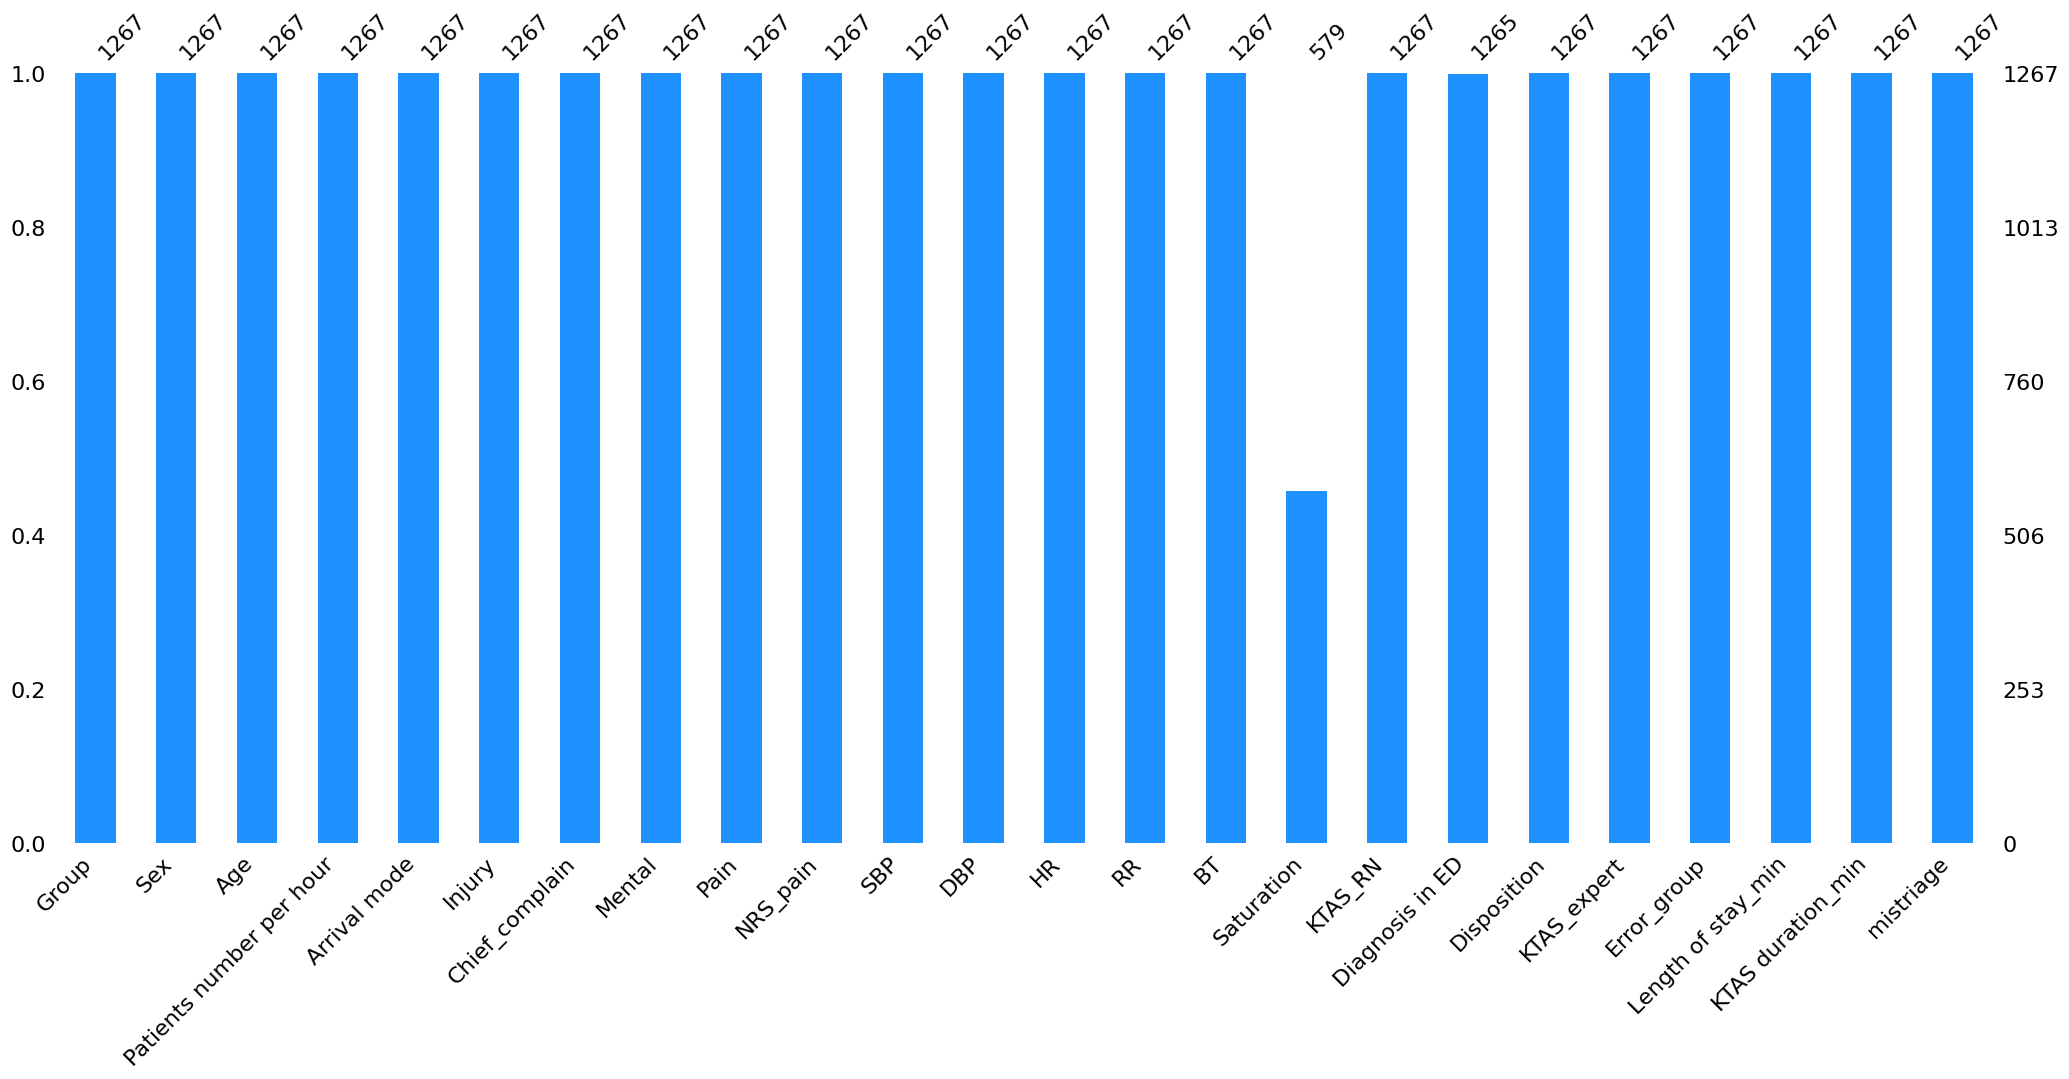

In [79]:
msno.bar(df, color="dodgerblue")

In [80]:
df.isnull().sum()


Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
Saturation                  688
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
mistriage                     0
dtype: int64

In [81]:
# Fill Missing Value

df["NRS_pain"] = df.groupby(["mistriage", "KTAS_expert"])["NRS_pain"].transform(lambda x: x.fillna(x.mode()[0]))
df["Saturation"] = df.groupby(["mistriage", "KTAS_expert"])["Saturation"].transform(lambda x: x.fillna(x.mode()[0]))
df["Diagnosis in ED"] = df.groupby(["mistriage", "KTAS_expert"])["Diagnosis in ED"].transform(lambda x: x.fillna(x.mode()[0]))

<Axes: >

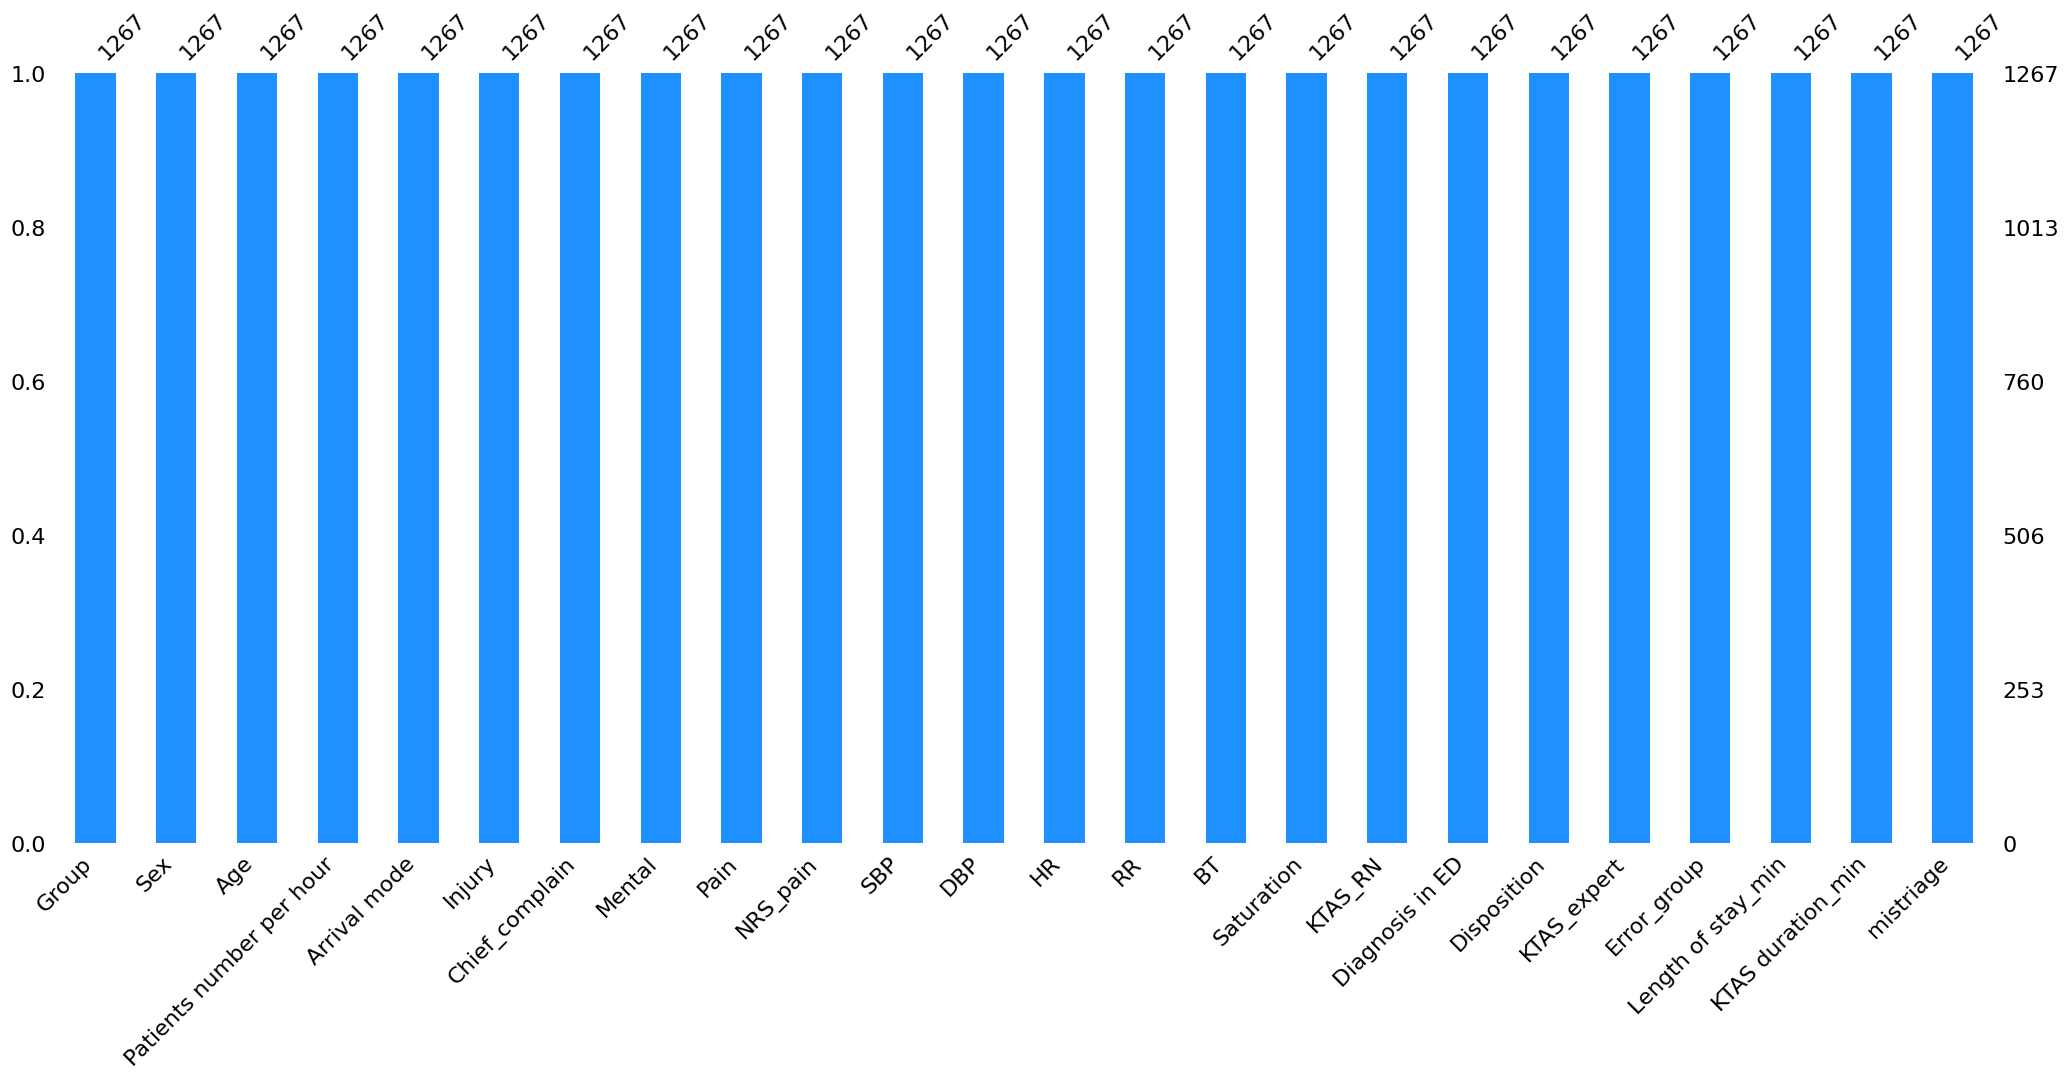

In [82]:
msno.bar(df, color="dodgerblue")

In [83]:
# List all numeric columns you want to clean
numeric_columns = [
    "KTAS duration_min",
    "NRS_pain",
    "SBP",
    "DBP",
    "HR",
    "RR",
    "BT",
    "Saturation",
    "Length of stay_min"
]

def clean_numeric_column(series):
    # Convert to string
    series = series.astype(str)

    # Replace commas with dots
    series = series.str.replace(",", ".", regex=False)

    # Remove any non-numeric characters except dot
    series = series.str.replace(r"[^0-9.]", "", regex=True)

    # Convert to numeric (errors become NaN)
    series = pd.to_numeric(series, errors='coerce')

    # Fill NaN with mode (most frequent value)
    if series.mode().size > 0:
        series = series.fillna(series.mode()[0])
    else:
        series = series.fillna(0)

    # Convert floats like 12.0 → 12 (optional)
    series = series.astype(float)
    if all(series.dropna().apply(float.is_integer)):
        series = series.astype(int)

    return series

# Apply cleaner to all numeric columns
for col in numeric_columns:
    df[col] = clean_numeric_column(df[col])

3.2. Feature Engineering

In [84]:
injury_cat = ['No','Yes']
sex_cat = ['Female','Male']
pain_cat = ['No','Yes']
mental_cat = ['Alert','Verbose Response','Pain Response','Unresponsive']
group_cat = ['Local ED (3th Degree)', 'Regional ED (4th Degree)']
arrival_mode_cat = ['Walking','Public Ambulance', 'Private Vehicle','Private Ambulance', 'Other','Other','Other']
disposition_cat = ['Discharge', 'Admission to Ward', 'Admission to ICU', 'Discharge', 'Transfer', 'Death', 'Surgery']
KTAS_cat = ['Emergency','Emergency','Emergency', 'Non-Emergency', 'Non-Emergency']
mistriage_cat = ['Normal Triage','Over Triage','Under Triage']

def clean_numeric(x):
    # Convert everything to string first
    x = str(x)

    # Replace comma with dot
    x = x.replace(",", ".")

    # Remove non-numeric characters (except dot)
    x = re.sub(r"[^0-9.]", "", x)

    # Convert to numeric, force errors to NaN
    return pd.to_numeric(x, errors="coerce")

import re

df["KTAS duration_min"] = df["KTAS duration_min"].apply(clean_numeric)
df["NRS_pain"] = df["NRS_pain"].apply(clean_numeric)

# Fill NaN using the mode (most common value)
df["KTAS duration_min"] = df["KTAS duration_min"].fillna(df["KTAS duration_min"].mode()[0])
df["NRS_pain"] = df["NRS_pain"].fillna(df["NRS_pain"].mode()[0])

# Convert floats like 12.0 → 12
df["KTAS duration_min"] = df["KTAS duration_min"].astype(int)
df["NRS_pain"] = df["NRS_pain"].astype(int)


###############################################################################################################################
#Categorical data were entered as numerical data. Therefore, it was categorized again categorically to make it more meaningful. 
###############################################################################################################################
df.loc[df["Sex"] == 1, "Sex"] = sex_cat[0]
df.loc[df["Sex"] == 2, "Sex"] = sex_cat[1]

df.loc[df["Injury"] == 1, "Injury"] = injury_cat[0]
df.loc[df["Injury"] == 2, "Injury"] = injury_cat[1]

df.loc[df["Pain"] == 0, "Pain"] = pain_cat[0]
df.loc[df["Pain"] == 1, "Pain"] = pain_cat[1]

df.loc[df["Mental"] == 1, "Mental"] = mental_cat[0]
df.loc[df["Mental"] == 2, "Mental"] = mental_cat[1]
df.loc[df["Mental"] == 3, "Mental"] = mental_cat[2]
df.loc[df["Mental"] == 4, "Mental"] = mental_cat[3]

df.loc[df["Group"] == 1, "Group"] = group_cat[0]
df.loc[df["Group"] == 2, "Group"] = group_cat[1]

df.loc[df["Arrival mode"] == 1, "Arrival mode"] = arrival_mode_cat[0]
df.loc[df["Arrival mode"] == 2, "Arrival mode"] = arrival_mode_cat[1]
df.loc[df["Arrival mode"] == 3, "Arrival mode"] = arrival_mode_cat[2]
df.loc[df["Arrival mode"] == 4, "Arrival mode"] = arrival_mode_cat[3]
df.loc[df["Arrival mode"] == 5, "Arrival mode"] = arrival_mode_cat[4]
df.loc[df["Arrival mode"] == 6, "Arrival mode"] = arrival_mode_cat[5]
df.loc[df["Arrival mode"] == 7, "Arrival mode"] = arrival_mode_cat[6]

df.loc[df["Disposition"] == 1, "Disposition"] = disposition_cat[0]
df.loc[df["Disposition"] == 2, "Disposition"] = disposition_cat[1]
df.loc[df["Disposition"] == 3, "Disposition"] = disposition_cat[2]
df.loc[df["Disposition"] == 4, "Disposition"] = disposition_cat[3]
df.loc[df["Disposition"] == 5, "Disposition"] = disposition_cat[4]
df.loc[df["Disposition"] == 6, "Disposition"] = disposition_cat[5]
df.loc[df["Disposition"] == 7, "Disposition"] = disposition_cat[6]

df.loc[df["KTAS_RN"] == 1, "KTAS_RN"] = KTAS_cat[0]
df.loc[df["KTAS_RN"] == 2, "KTAS_RN"] = KTAS_cat[1]
df.loc[df["KTAS_RN"] == 3, "KTAS_RN"] = KTAS_cat[2]
df.loc[df["KTAS_RN"] == 4, "KTAS_RN"] = KTAS_cat[3]
df.loc[df["KTAS_RN"] == 5, "KTAS_RN"] = KTAS_cat[4]

df.loc[df["KTAS_expert"] == 1, "KTAS_expert"] = KTAS_cat[0]
df.loc[df["KTAS_expert"] == 2, "KTAS_expert"] = KTAS_cat[1]
df.loc[df["KTAS_expert"] == 3, "KTAS_expert"] = KTAS_cat[2]
df.loc[df["KTAS_expert"] == 4, "KTAS_expert"] = KTAS_cat[3]
df.loc[df["KTAS_expert"] == 5, "KTAS_expert"] = KTAS_cat[4]

df.loc[df["mistriage"] == 0, "mistriage"] = mistriage_cat[0]
df.loc[df["mistriage"] == 1, "mistriage"] = mistriage_cat[1]
df.loc[df["mistriage"] == 2, "mistriage"] = mistriage_cat[2]
###############################################################################################################################
##############               Nonsense data was encountered in variables containing numerical data.                 ############
##############                 These values have been replaced by the mode of the variable.                        ############
###############################################################################################################################

df[["SBP","DBP","HR","RR","BT","Saturation"]] = df[["SBP","DBP","HR","RR","BT","Saturation"]].replace("??",0).astype(str).astype(float)
df['SBP'] = df['SBP'].replace(0,df['SBP'].mode()[0])
df['DBP'] = df['DBP'].replace(0,df['DBP'].mode()[0])

###############################################################################################################################
##############                                        Feature Engineering                                          ############
###############################################################################################################################
interval = (0, 25, 45, 60, 100)
cats = ['Young', 'Adult', 'Mid_Age', 'Old']
df["New_Age"] = pd.cut(df.Age, interval, labels=cats)

df.loc[df['SBP'] < 80, 'New_SBP'] = 'Low'
df.loc[(df["SBP"] >= 80) & (df["SBP"] <= 120), 'New_SBP'] = 'Normal'
df.loc[df['SBP'] > 120, 'New_SBP'] = 'High'

df.loc[df['DBP'] < 60, 'New_DBP'] = 'Low'
df.loc[(df["DBP"] >= 60) & (df["DBP"] <= 80), 'New_DBP'] = 'Normal'
df.loc[df['DBP'] > 80, 'New_DBP'] = 'High'

df.loc[df['HR'] < 45, 'New_HR'] = 'Low'
df.loc[(df["HR"] >= 45) & (df["HR"] <= 100), 'New_HR'] = 'Normal'
df.loc[df['HR'] > 100, 'New_HR'] = 'High'

df.loc[df['RR'] < 12, 'New_RR'] = 'Low'
df.loc[(df["RR"] >= 12) & (df["RR"] <= 25), 'New_RR'] = 'Normal'
df.loc[df['RR'] > 25, 'New_RR'] = 'High'

df.loc[df['BT'] < 36.4, 'New_BT'] = 'Low'
df.loc[(df["BT"] >= 36.4) & (df["BT"] <= 37.6), 'New_BT'] = 'Normal'
df.loc[df['BT'] > 37.6, 'New_BT'] = 'High'

df.loc[df['NRS_pain'] < 3, 'New_NRS_pain'] = 'Low Pain'
df.loc[(df["NRS_pain"] >= 3) & (df["NRS_pain"] <= 7), 'New_NRS_pain'] = 'Pain'
df.loc[df['NRS_pain'] > 7, 'New_NRS_pain'] = 'High Pain'

df.loc[df['KTAS duration_min'] < 10, 'New_KTAS_duration_min'] = 'Immediate'
df.loc[(df["KTAS duration_min"] >= 10) & (df["KTAS duration_min"] <= 60), 'New_KTAS_duration_min'] = 'Very Urgent'
df.loc[(df["KTAS duration_min"] >= 61) & (df["KTAS duration_min"] <= 120), 'New_KTAS_duration_min'] = 'Urgent'
df.loc[(df["KTAS duration_min"] >= 121) & (df["KTAS duration_min"] <= 240), 'New_KTAS_duration_min'] = 'Standart'
df.loc[df['KTAS duration_min'] > 240, 'New_KTAS_duration_min'] = 'Non-Urgent'

df.loc[df['Length of stay_min'] < 10, 'New_Length_of_stay_min'] = 'Immediate'
df.loc[(df["Length of stay_min"] >= 10) & (df["Length of stay_min"] <= 60), 'New_Length_of_stay_min'] = 'Very Urgent'
df.loc[(df["Length of stay_min"] >= 61) & (df["Length of stay_min"] <= 120), 'New_Length_of_stay_min'] = 'Urgent'
df.loc[(df["Length of stay_min"] >= 121) & (df["Length of stay_min"] <= 240), 'New_Length_of_stay_min'] = 'Standart'
df.loc[df['Length of stay_min'] > 240, 'New_Length_of_stay_min'] = 'Non-Urgent'

df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage,New_Age,New_SBP,New_DBP,New_HR,New_RR,New_BT,New_NRS_pain,New_KTAS_duration_min,New_Length_of_stay_min
0,Regional ED (4th Degree),Male,71,3,Private Vehicle,Yes,right ocular pain,Alert,Yes,2,160.000,100.000,84.000,18.000,36.600,100.000,Emergency,Corneal abrasion,Discharge,Non-Emergency,2,86,5,Over Triage,Old,High,High,Normal,Normal,Normal,Low Pain,Immediate,Urgent
1,Local ED (3th Degree),Female,56,12,Private Vehicle,Yes,right forearm burn,Alert,Yes,2,137.000,75.000,60.000,20.000,36.500,98.000,Non-Emergency,"Burn of hand, firts degree dorsum",Discharge,Non-Emergency,4,64,3,Over Triage,Mid_Age,High,Normal,Normal,Normal,Normal,Low Pain,Immediate,Urgent
2,Regional ED (4th Degree),Female,68,8,Public Ambulance,Yes,"arm pain, Lt",Alert,Yes,2,130.000,80.000,102.000,20.000,36.600,98.000,Non-Emergency,"Fracture of surgical neck of humerus, closed",Admission to Ward,Non-Emergency,4,862,1,Over Triage,Old,High,Normal,High,Normal,Normal,Low Pain,Immediate,Non-Urgent
3,Local ED (3th Degree),Male,71,8,Walking,No,ascites tapping,Alert,Yes,3,139.000,94.000,88.000,20.000,36.500,98.000,Non-Emergency,Alcoholic liver cirrhosis with ascites,Discharge,Non-Emergency,6,108,9,Over Triage,Old,High,High,Normal,Normal,Normal,Pain,Immediate,Urgent
4,Local ED (3th Degree),Male,58,4,Private Vehicle,No,"distension, abd",Alert,Yes,3,91.000,67.000,93.000,18.000,36.500,98.000,Non-Emergency,Ascites,Discharge,Non-Emergency,8,109,6,Over Triage,Mid_Age,Normal,Normal,Normal,Normal,Normal,Pain,Immediate,Urgent


In [85]:
print(df['mistriage'].value_counts())

over_triage_count = df['mistriage'].value_counts().get('Over Triage', 0)
print(f"Number of 'Over Triage' samples: {over_triage_count}")


mistriage
Normal Triage    1081
Under Triage      131
Over Triage        55
Name: count, dtype: int64
Number of 'Over Triage' samples: 55


3.3. Outlier Anaysis

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def outlier_thresholds(dataframe, variable, lower_quantile=0.05, upper_quantile=0.95):
    """
    Calculate lower and upper outlier thresholds using interquartile method on specified quantiles.
    """
    q1 = dataframe[variable].quantile(lower_quantile)
    q3 = dataframe[variable].quantile(upper_quantile)
    iqr = q3 - q1
    low_limit = q1 - 1.5 * iqr
    up_limit = q3 + 1.5 * iqr
    return low_limit, up_limit

def has_outliers(dataframe, num_col_names, plot=False):
    """
    Check numeric columns for outliers, return summary DataFrame with counts and percentages.
    Optionally plots boxplots for each column.
    """
    results = []
    
    for col in num_col_names:
        if not pd.api.types.is_numeric_dtype(dataframe[col]):
            print(f"Skipping '{col}' (not numeric)")
            continue

        low_limit, up_limit = outlier_thresholds(dataframe, col)
        outlier_mask = (dataframe[col] < low_limit) | (dataframe[col] > up_limit)
        num_outliers = outlier_mask.sum()
        pct_outliers = num_outliers / len(dataframe) * 100

        results.append({
            "variable": col,
            "outliers_count": num_outliers,
            "outliers_percentage": round(pct_outliers, 3)
        })

        if plot:
            sns.boxplot(x=dataframe[col])
            plt.title(f"Boxplot of {col}")
            plt.show()

    return pd.DataFrame(results)


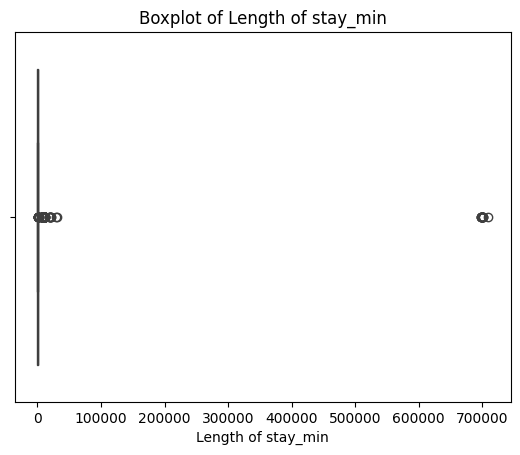

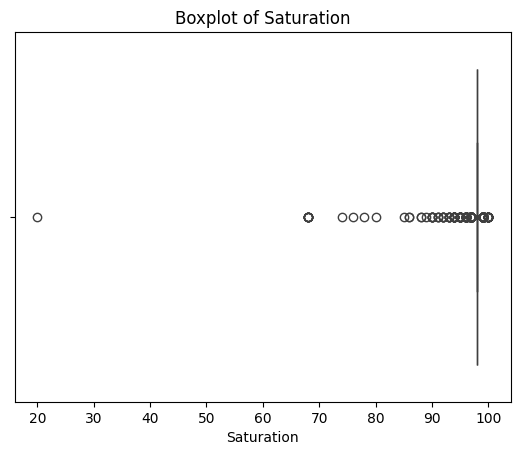

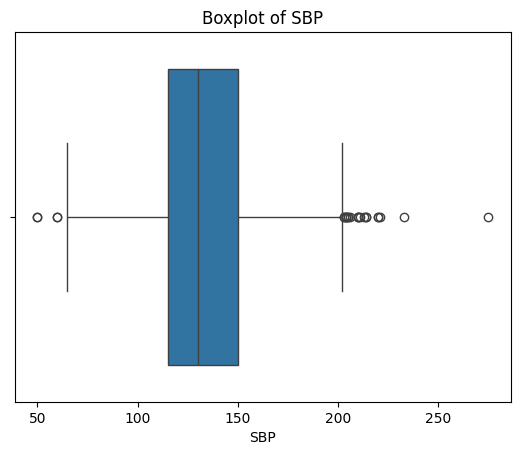

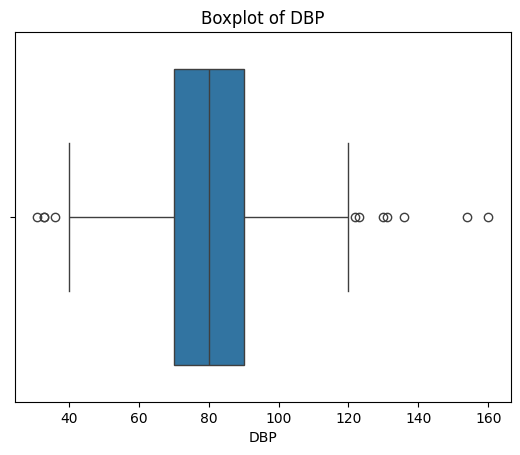

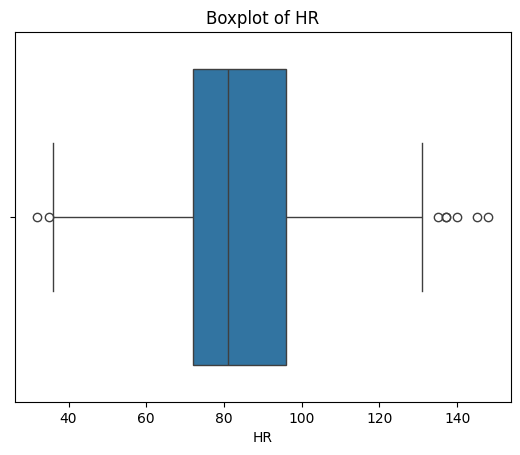

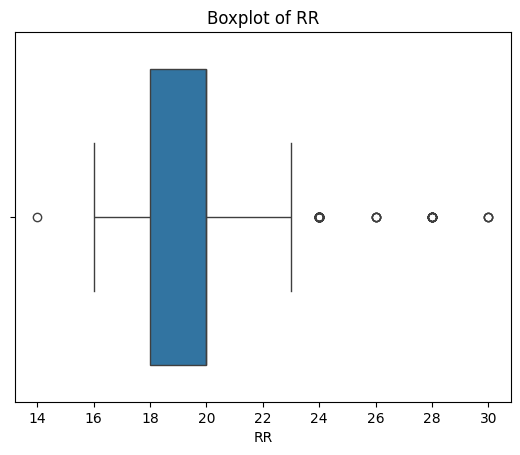

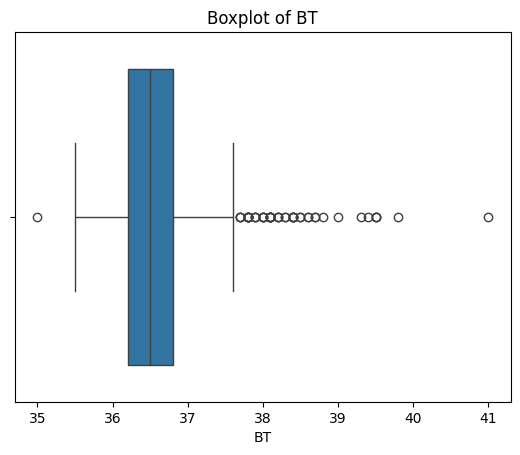

             variable  outliers_count  outliers_percentage
0  Length of stay_min              19                1.500
1          Saturation              18                1.421
2                 SBP               0                0.000
3                 DBP               0                0.000
4                  HR               0                0.000
5                  RR               0                0.000
6                  BT               2                0.158


In [87]:
numeric_columns = ["Length of stay_min","Saturation","SBP","DBP","HR","RR","BT"]
outlier_summary = has_outliers(df, numeric_columns, plot=True)
print(outlier_summary)


In [88]:
# Define numeric columns
numeric_columns = ["Length of stay_min","Saturation","SBP","DBP","HR","RR","BT"]

# Function to replace outliers with thresholds
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

# Apply function to all numeric columns
for col in numeric_columns:
    replace_with_thresholds(df, col)


In [89]:
# Check updated outliers after capping
has_outliers(df, numeric_columns)


,variable,outliers_count,outliers_percentage
0,Length of stay_min,0,0.000
1,Saturation,0,0.000
2,SBP,0,0.000
3,DBP,0,0.000
4,HR,0,0.000
5,RR,0,0.000
6,BT,0,0.000


In [90]:
# View summary statistics
df[numeric_columns].describe()


,Length of stay_min,Saturation,SBP,DBP,HR,RR,BT
count,1267.000,1267.000,1267.000,1267.000,1267.000,1267.000,1267.000
mean,1955.784,97.622,133.380,79.785,83.901,19.515,36.571
std,4413.575,1.583,27.072,14.980,16.519,2.000,0.539
min,0.000,89.000,50.000,31.000,32.000,14.000,35.000
25%,133.000,98.000,115.000,70.000,72.000,18.000,36.200
50%,274.000,98.000,130.000,80.000,81.000,20.000,36.500
75%,606.500,98.000,150.000,90.000,96.000,20.000,36.800
max,25185.000,100.000,275.000,160.000,148.000,30.000,39.750


4. DATA VISUALIZATION

<Axes: xlabel='KTAS duration_min', ylabel='Density'>

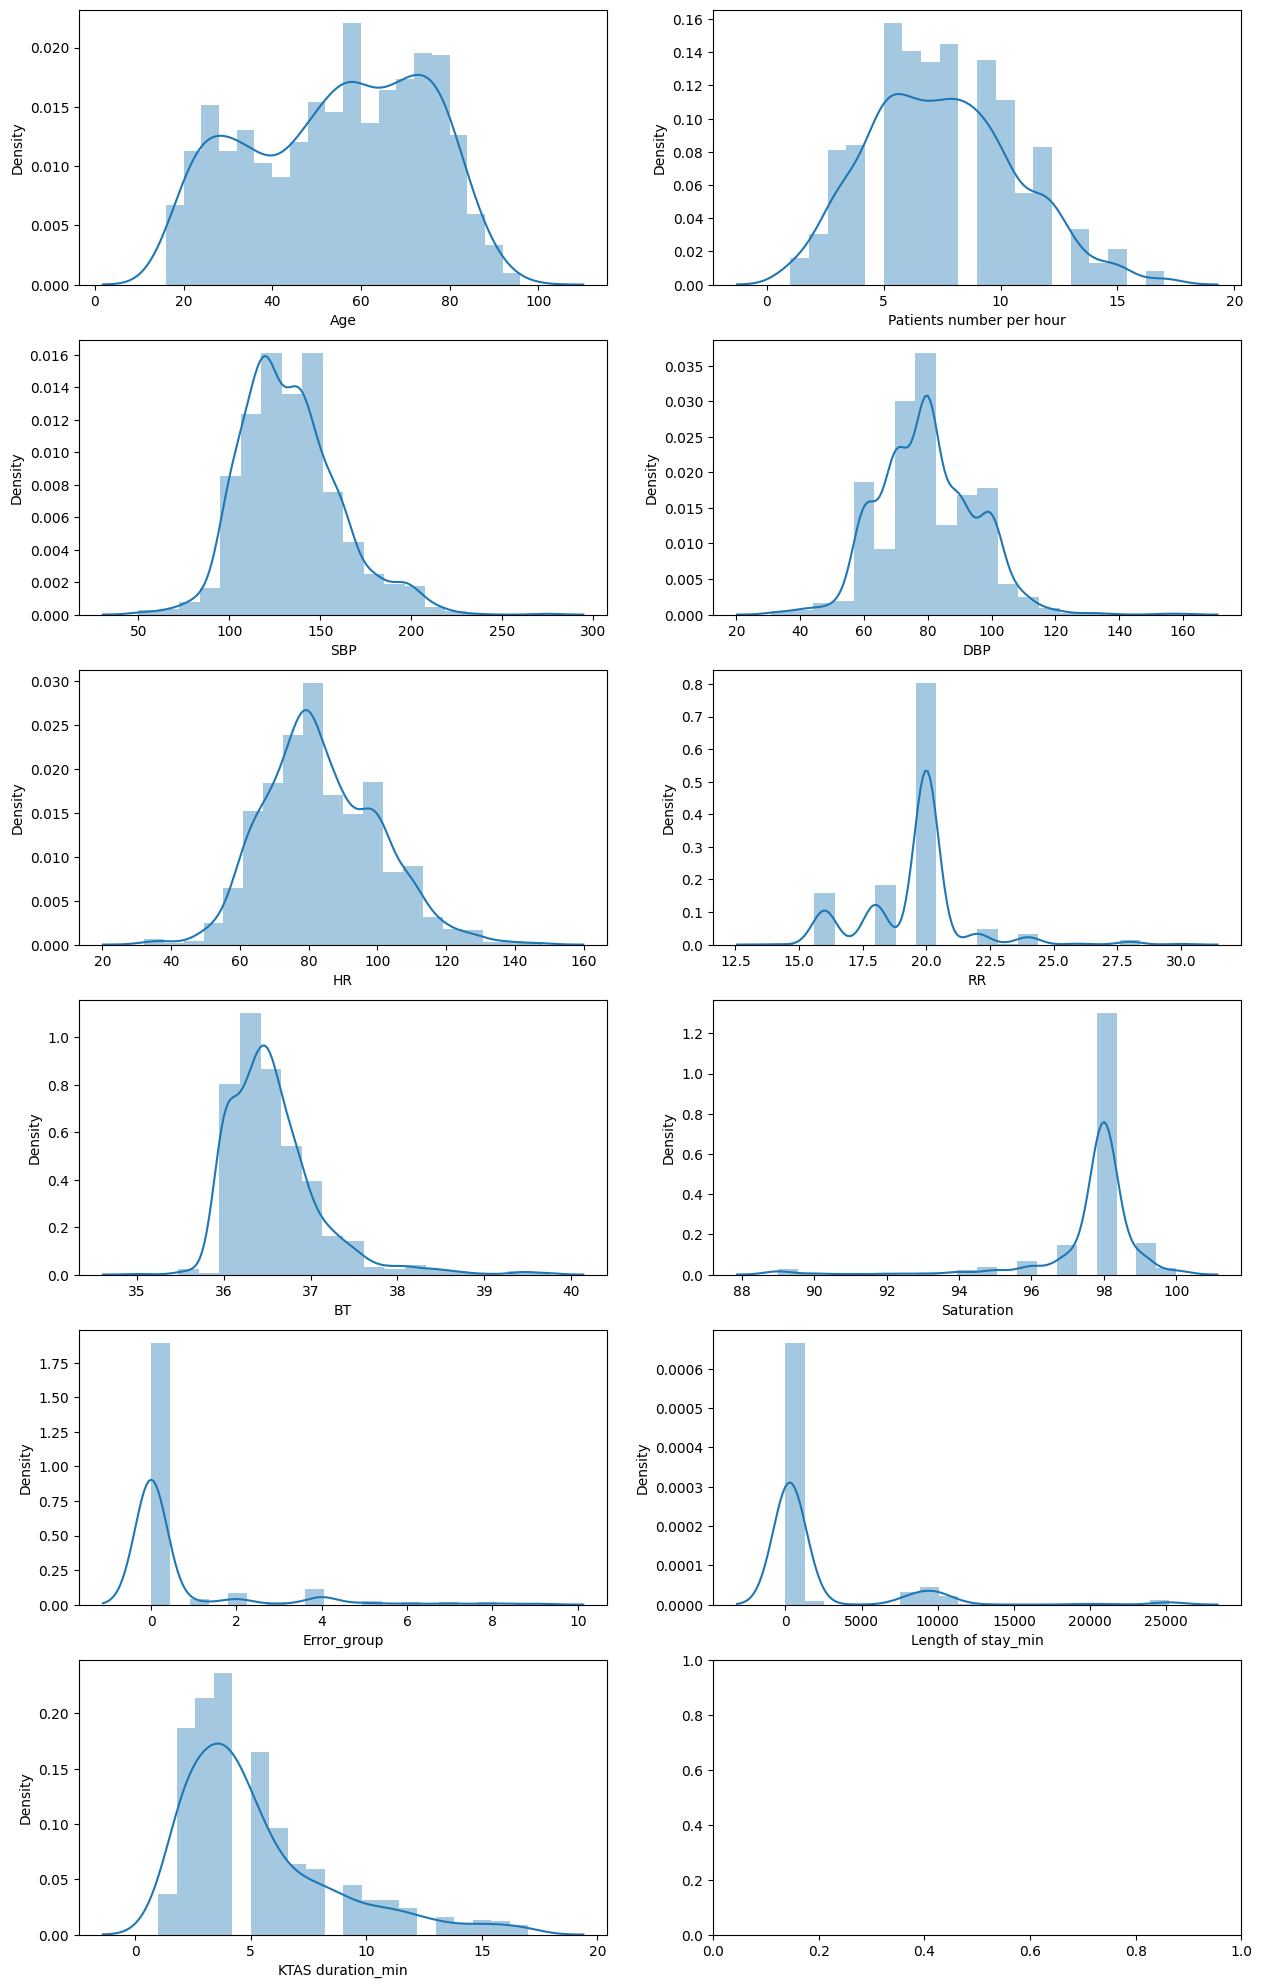

In [91]:
# Histogram and density graphs of all variables were accessed.
fig, ax = plt.subplots(6,2, figsize=(15,25))
sns.distplot(df['Age'], bins = 20, ax=ax[0,0]) 
sns.distplot(df['Patients number per hour'], bins = 20, ax=ax[0,1]) 
sns.distplot(df['SBP'], bins = 20, ax=ax[1,0]) 
sns.distplot(df['DBP'], bins = 20, ax=ax[1,1]) 
sns.distplot(df['HR'], bins = 20, ax=ax[2,0])
sns.distplot(df['RR'], bins = 20, ax=ax[2,1])
sns.distplot(df['BT'], bins = 20, ax=ax[3,0]) 
sns.distplot(df['Saturation'], bins = 20, ax=ax[3,1]) 
sns.distplot(df['Error_group'], bins = 20, ax=ax[4,0])
sns.distplot(df['Length of stay_min'], bins = 20, ax=ax[4,1]) 
sns.distplot(df['KTAS duration_min'], bins = 20, ax=ax[5,0])

<Axes: xlabel='New_Length_of_stay_min', ylabel='count'>

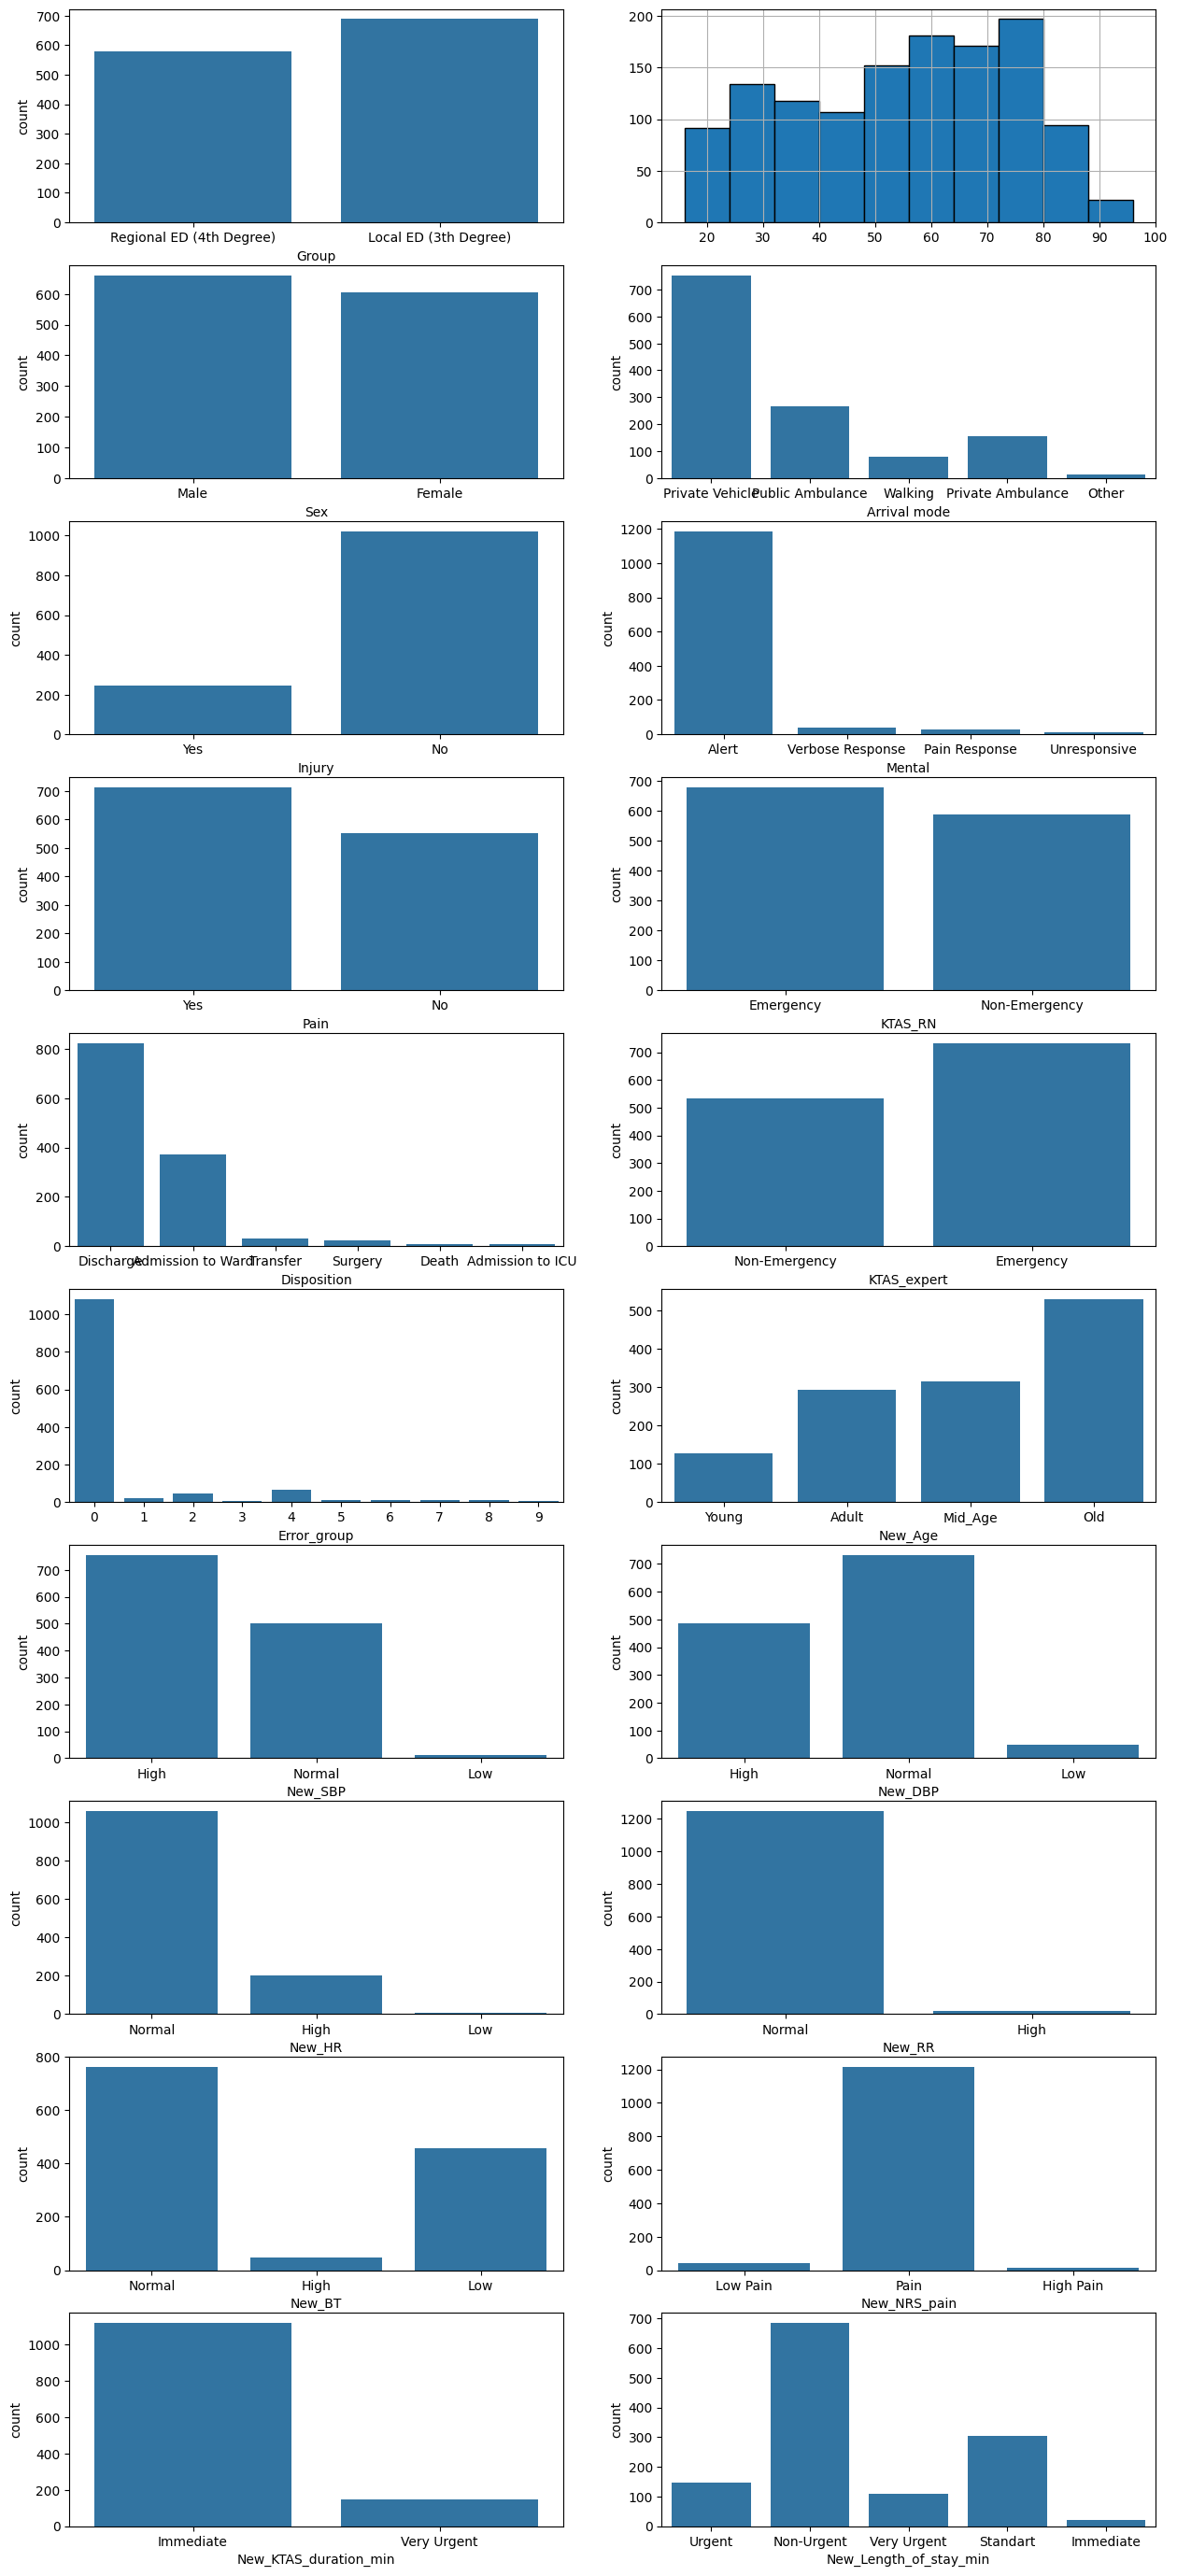

In [92]:
fig, ax = plt.subplots(10, 2, figsize=(15, 35))

sns.countplot(x='Group', data=df, ax=ax[0,0])
df["Age"].hist(edgecolor="black", ax=ax[0,1])

sns.countplot(x='Sex', data=df, ax=ax[1,0])
sns.countplot(x='Arrival mode', data=df, ax=ax[1,1])

sns.countplot(x='Injury', data=df, ax=ax[2,0])
sns.countplot(x='Mental', data=df, ax=ax[2,1])

sns.countplot(x='Pain', data=df, ax=ax[3,0])
sns.countplot(x='KTAS_RN', data=df, ax=ax[3,1])

sns.countplot(x='Disposition', data=df, ax=ax[4,0])
sns.countplot(x='KTAS_expert', data=df, ax=ax[4,1])

sns.countplot(x='Error_group', data=df, ax=ax[5,0])
sns.countplot(x='New_Age', data=df, ax=ax[5,1])

sns.countplot(x='New_SBP', data=df, ax=ax[6,0])
sns.countplot(x='New_DBP', data=df, ax=ax[6,1])

sns.countplot(x='New_HR', data=df, ax=ax[7,0])
sns.countplot(x='New_RR', data=df, ax=ax[7,1])

sns.countplot(x='New_BT', data=df, ax=ax[8,0])
sns.countplot(x='New_NRS_pain', data=df, ax=ax[8,1])

sns.countplot(x='New_KTAS_duration_min', data=df, ax=ax[9,0])
sns.countplot(x='New_Length_of_stay_min', data=df, ax=ax[9,1])


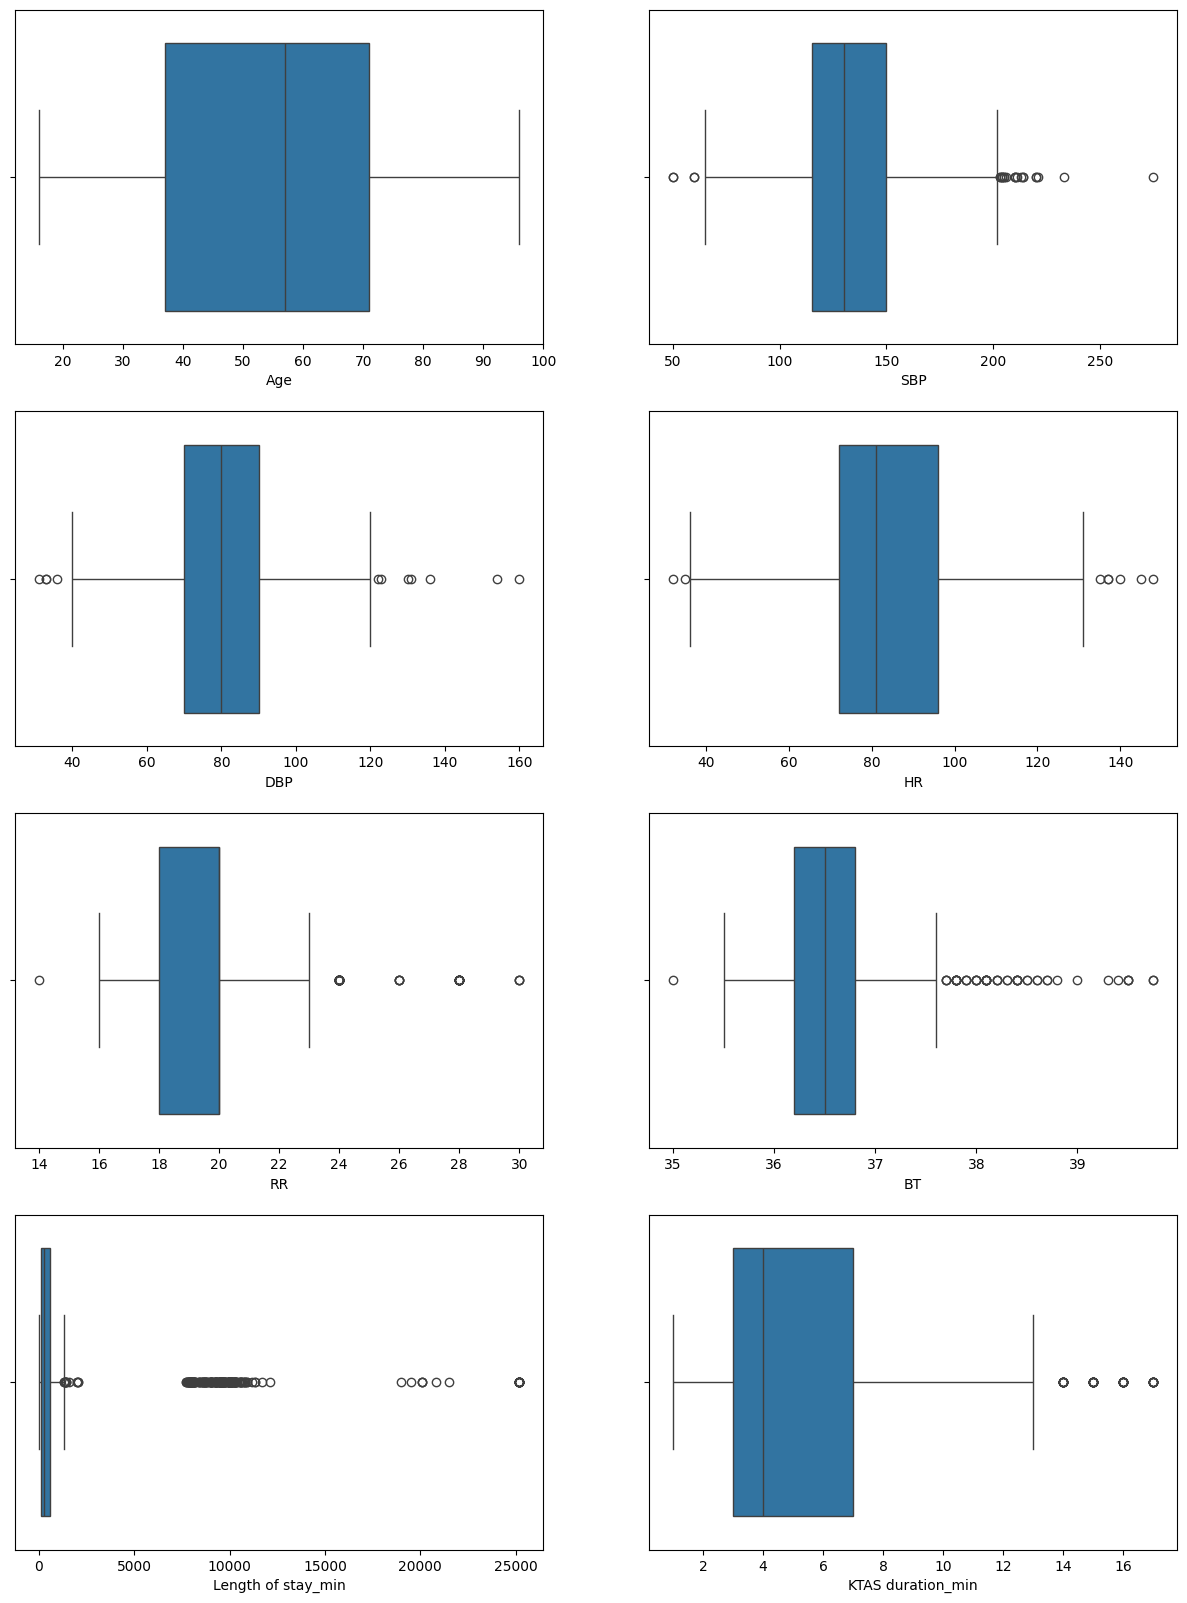

In [93]:
fig, ax = plt.subplots(4,2, figsize=(15,20))
sns.boxplot(x=df["Age"], ax=ax[0,0]);
sns.boxplot(x=df["SBP"], ax=ax[0,1]);
sns.boxplot(x=df["DBP"], ax=ax[1,0]);
sns.boxplot(x=df["HR"], ax=ax[1,1]);
sns.boxplot(x=df["RR"], ax=ax[2,0]);
sns.boxplot(x=df["BT"], ax=ax[2,1]);
sns.boxplot(x=df["Length of stay_min"], ax=ax[3,0]);
sns.boxplot(x=df["KTAS duration_min"], ax=ax[3,1]);

5. Data Segmentetion with Machine Learning Models

5.1. One Hot Encoding and Robust Scaler

In [94]:
def one_hot_encoder(dataframe, categorical_columns, nan_as_category=False):
    original_columns = list(dataframe.columns)
    dataframe = pd.get_dummies(dataframe, columns=categorical_columns,
                               dummy_na=nan_as_category, drop_first=True)
    new_columns = [col for col in dataframe.columns if col not in original_columns]
    return dataframe, new_columns

def robust_scaler(variable):
    var_median = variable.median()
    quartile1 = variable.quantile(0.05)
    quartile3 = variable.quantile(0.95)
    interquantile_range = quartile3 - quartile1
    if int(interquantile_range) == 0:
        quartile1 = variable.quantile(0.05)
        quartile3 = variable.quantile(0.95)
        interquantile_range = quartile3 - quartile1
        z = (variable - var_median) / interquantile_range
        return round(z, 3)
    else:
        z = (variable - var_median) / interquantile_range
    return round(z, 3)

In [95]:
new_df = df[["Group", "Sex", "Patients number per hour", "Arrival mode", "Injury", "Mental", "Pain", "Saturation", "KTAS_RN",
"Disposition", "KTAS_expert", "Length of stay_min", "mistriage", "New_Age", "New_SBP", "New_DBP", "New_HR",
"New_RR", "New_BT", "New_NRS_pain", "New_KTAS_duration_min", "New_Length_of_stay_min"]]
new_df.head()

,Group,Sex,Patients number per hour,Arrival mode,Injury,Mental,Pain,Saturation,KTAS_RN,Disposition,KTAS_expert,Length of stay_min,mistriage,New_Age,New_SBP,New_DBP,New_HR,New_RR,New_BT,New_NRS_pain,New_KTAS_duration_min,New_Length_of_stay_min
0,Regional ED (4th Degree),Male,3,Private Vehicle,Yes,Alert,Yes,100.000,Emergency,Discharge,Non-Emergency,86.000,Over Triage,Old,High,High,Normal,Normal,Normal,Low Pain,Immediate,Urgent
1,Local ED (3th Degree),Female,12,Private Vehicle,Yes,Alert,Yes,98.000,Non-Emergency,Discharge,Non-Emergency,64.000,Over Triage,Mid_Age,High,Normal,Normal,Normal,Normal,Low Pain,Immediate,Urgent
2,Regional ED (4th Degree),Female,8,Public Ambulance,Yes,Alert,Yes,98.000,Non-Emergency,Admission to Ward,Non-Emergency,862.000,Over Triage,Old,High,Normal,High,Normal,Normal,Low Pain,Immediate,Non-Urgent
3,Local ED (3th Degree),Male,8,Walking,No,Alert,Yes,98.000,Non-Emergency,Discharge,Non-Emergency,108.000,Over Triage,Old,High,High,Normal,Normal,Normal,Pain,Immediate,Urgent
4,Local ED (3th Degree),Male,4,Private Vehicle,No,Alert,Yes,98.000,Non-Emergency,Discharge,Non-Emergency,109.000,Over Triage,Mid_Age,Normal,Normal,Normal,Normal,Normal,Pain,Immediate,Urgent


In [96]:
like_num = [col for col in new_df.columns if new_df[col].dtypes != 'O' and len(new_df[col].value_counts()) > 10]
cols_need_scale = [col for col in new_df.columns if col not in like_num
                   and col not in 'mistriage']

In [97]:
for col in like_num:
    new_df[col] = robust_scaler(new_df[col])

new_df, one_hot_encodeds = one_hot_encoder(new_df, cols_need_scale)

In [98]:
X = new_df.drop('mistriage', axis=1)
y = np.ravel(new_df[['mistriage']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 357)

In [99]:
X_train.head()

,Patients number per hour,Saturation,Length of stay_min,Group_Regional ED (4th Degree),Sex_Male,Arrival mode_Private Ambulance,Arrival mode_Private Vehicle,Arrival mode_Public Ambulance,Arrival mode_Walking,Injury_Yes,Mental_Pain Response,Mental_Unresponsive,Mental_Verbose Response,Pain_Yes,KTAS_RN_Non-Emergency,Disposition_Admission to Ward,Disposition_Death,Disposition_Discharge,Disposition_Surgery,Disposition_Transfer,KTAS_expert_Non-Emergency,New_Age_Adult,New_Age_Mid_Age,New_Age_Old,New_SBP_Low,New_SBP_Normal,New_DBP_Low,New_DBP_Normal,New_HR_Low,New_HR_Normal,New_RR_Normal,New_BT_Low,New_BT_Normal,New_NRS_pain_Low Pain,New_NRS_pain_Pain,New_KTAS_duration_min_Very Urgent,New_Length_of_stay_min_Non-Urgent,New_Length_of_stay_min_Standart,New_Length_of_stay_min_Urgent,New_Length_of_stay_min_Very Urgent
428,-0.500,-0.750,0.966,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,True,False,True,False,False,False
772,-0.200,0.000,0.006,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,True,False,False,True,False,True,False,False,False
873,0.300,0.000,-0.020,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,True,False,True,False,True,False,False,False,True,False
572,0.200,0.000,-0.013,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,True,True,False,True,False,True,False,False,True,False,False
385,0.200,-0.500,0.968,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,False,False,False,True,True,False,True,False,True,False,True,False,False,False


In [100]:
# Let's set the parameters to find the best parameter to use in our models. These parameters will be chosen as the best to visit with GridSearchCV.
rf_params = {"max_depth": [3, 5, 8],
             "max_features": [8, 15, 25],
             "n_estimators": [200, 500, 1000],
             "min_samples_split": [2, 5, 10]}

lgbm_params = {"learning_rate": [0.01, 0.1],
               "n_estimators": [200, 500, 1000],
               "max_depth": [3, 5, 8],
               "colsample_bytree": [1, 0.8, 0.5]}

#xgb_params = {"learning_rate": [0.1, 0.01],
#              "max_depth": [3, 5, 8],
#              "n_estimators": [200, 500, 1000],
#              "colsample_bytree": [0.7, 1]}

rf = RandomForestClassifier(random_state=357)
lgbm = LGBMClassifier(random_state=357)
#xgb = XGBClassifier(random_state=357)

# Let's try the parameters one by one with the help of GridSearchCV and find the best parameter.
gs_cv_rf = GridSearchCV(rf, rf_params, cv=10, n_jobs=-1, verbose=2).fit(X_train, y_train)
gs_cv_lgbm = GridSearchCV(lgbm, lgbm_params, cv=10, n_jobs=-1, verbose=2).fit(X_train, y_train)
#gs_cv_xgb = GridSearchCV(xgb, xgb_params, cv=10, n_jobs=-1, verbose=2).fit(X_train, y_train)

Fitting 10 folds for each of 81 candidates, totalling 810 fits
Fitting 10 folds for each of 54 candidates, totalling 540 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 220
[LightGBM] [Info] Number of data points in the train set: 1013, number of used features: 34
[LightGBM] [Info] Start training from score -0.166067
[LightGBM] [Info] Start training from score -3.049470
[LightGBM] [Info] Start training from score -2.247843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [101]:
#lgr_tuned = LogisticRegression(random_state=357).fit(X_train, y_train)
knn_tuned = KNeighborsClassifier().fit(X_train, y_train)
svm_tuned = SVC(random_state=357,gamma='auto').fit(X_train, y_train)
gnb_tuned = GaussianNB().fit(X_train, y_train)
dtc_tuned = DecisionTreeClassifier(random_state=357).fit(X_train, y_train)

# Let's tune the models with the best parameters found.
rf_tuned = RandomForestClassifier(**gs_cv_rf.best_params_, random_state=357).fit(X_train, y_train)
lgbm_tuned = LGBMClassifier(**gs_cv_lgbm.best_params_, random_state=357).fit(X_train, y_train)
#xgb_tuned = XGBClassifier(**gs_cv_xgb.best_params_, random_state=357).fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 220
[LightGBM] [Info] Number of data points in the train set: 1013, number of used features: 34
[LightGBM] [Info] Start training from score -0.166067
[LightGBM] [Info] Start training from score -3.049470
[LightGBM] [Info] Start training from score -2.247843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [102]:
# Result
models = [#("LGR", lgr_tuned),
          ("KNN", knn_tuned),
          ("SVM", svm_tuned),
          ("GNB", gnb_tuned),
          ("DTC", dtc_tuned),
          ("RF", rf_tuned),
          ("LGBM", lgbm_tuned),
          #("XGB", xgb_tuned)
         ]

for name, model in models:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    msg = "%s: (%f)" % (name, acc)
    print(msg)

KNN: (0.893701)
SVM: (0.952756)
GNB: (0.074803)
DTC: (0.874016)
RF: (0.956693)
LGBM: (0.960630)


In [103]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, model in models:
    print(f"\n===== {name} =====")
    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



===== KNN =====
Confusion Matrix:
[[223   0   0]
 [  7   0   0]
 [ 20   0   4]]

Classification Report:
               precision    recall  f1-score   support

Normal Triage       0.89      1.00      0.94       223
  Over Triage       0.00      0.00      0.00         7
 Under Triage       1.00      0.17      0.29        24

     accuracy                           0.89       254
    macro avg       0.63      0.39      0.41       254
 weighted avg       0.88      0.89      0.85       254


===== SVM =====
Confusion Matrix:
[[223   0   0]
 [  7   0   0]
 [  5   0  19]]

Classification Report:
               precision    recall  f1-score   support

Normal Triage       0.95      1.00      0.97       223
  Over Triage       0.00      0.00      0.00         7
 Under Triage       1.00      0.79      0.88        24

     accuracy                           0.95       254
    macro avg       0.65      0.60      0.62       254
 weighted avg       0.93      0.95      0.94       254


===== GNB ===

In [104]:
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split dataset with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTEENN to balance and clean the training data
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

# Define models, add class_weight='balanced' where applicable
models = {
    "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=42),  # LightGBM handles imbalance differently
    "SVM": SVC(random_state=42, class_weight='balanced', probability=True, gamma='auto')
}

# Define hyperparameter grids for each model
param_grids = {
    "RandomForest": {
        'n_estimators': [200, 500],
        'max_depth': [5, 10],
        'min_samples_split': [2, 5]
    },
    "LightGBM": {
        'n_estimators': [200, 500],
        'max_depth': [5, 10],
        'learning_rate': [0.01, 0.1]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2  # Optional: shows progress of the grid search
    )
    grid_search.fit(X_train_res, y_train_res)
    best_model = grid_search.best_estimator_
    
    print(f"Best hyperparameters for {name}: {grid_search.best_params_}")
    
    y_pred = best_model.predict(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")



Training RandomForest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best hyperparameters for RandomForest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Confusion Matrix:
[[204   5   8]
 [  9   1   1]
 [  7   0  19]]

Classification Report:
               precision    recall  f1-score   support

Normal Triage       0.93      0.94      0.93       217
  Over Triage       0.17      0.09      0.12        11
 Under Triage       0.68      0.73      0.70        26

     accuracy                           0.88       254
    macro avg       0.59      0.59      0.58       254
 weighted avg       0.87      0.88      0.87       254

Accuracy: 0.8819

Training LightGBM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overh